<a href="https://colab.research.google.com/github/nerdycore/Thesis_Project/blob/main/HybridMangoDisease_resNet_graphSage_colab_with_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

# Path to your ZIP file in Drive
zip_path = '/content/drive/MyDrive/Thesis/Dataset/MangoFruit&Leaf.zip'  # Adjust if needed

# Extract to local VM storage
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction complete!")

Extraction complete!


In [ ]:
import torch
print(torch.__version__)
import pandas
print(pandas.__version__)
#import torch_geometric
#print(torch_geometric.__version__)


2.11.0+cu128
2.2.2


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121



Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 34.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 152.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 203.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 218.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.3.0+cu121
CUDA: 12.1
CUDA available: True


ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib


In [ ]:
import torch
import torchvision
import torch_geometric
print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"PyG: {torch_geometric.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


PyTorch: 2.3.0+cu121
TorchVision: 0.18.0+cu121
PyG: 2.8.0.post1
CUDA available: True


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
12.8


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

# Choose your seed (you can use any integer)
SEED = 123
set_seed(SEED)

All seeds set to 123


In [ ]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
import imageio.v2 as io
from skimage.transform import resize
import pathlib
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, BatchNorm
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight
import json

In [ ]:
import pathlib

data_dir = pathlib.Path("/content/dataset/MangoFruit&Leaf")

# Define valid image extensions
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

mango_disease_dict = {
    "alternaria_fruit": [f for f in data_dir.glob("Alternaria_Fruit/*") if f.suffix.lower() in image_extensions],
    "anthracnose_fruit": [f for f in data_dir.glob("Anthracnose_Fruit/*") if f.suffix.lower() in image_extensions],
    'mango_scab_fruit': [f for f in data_dir.glob("MangoScab_Fruit/*") if f.suffix.lower() in image_extensions],
    "stem_end_rot_fruit": [f for f in data_dir.glob("StemEndrot_Fruit/*") if f.suffix.lower() in image_extensions],
    'healthy_fruit': [f for f in data_dir.glob("Healthy_Fruit/*") if f.suffix.lower() in image_extensions],

    "anthracnose_leaf": [f for f in data_dir.glob("Anthracnose_Leaf/*") if f.suffix.lower() in image_extensions],
    'powdery_mildew_leaf': [f for f in data_dir.glob("PowderyMildew_Leaf/*") if f.suffix.lower() in image_extensions],
    "scooty_mould_leaf": [f for f in data_dir.glob("ScootyMould_Leaf/*") if f.suffix.lower() in image_extensions],
    'healthy_leaf': [f for f in data_dir.glob("Healthy_Leaf/*") if f.suffix.lower() in image_extensions],
}

# Rest of your code stays exactly the same
mango_disease_labels = {
    'alternaria_fruit' : 0, 'anthracnose_fruit': 1, 'mango_scab_fruit': 2,
    "stem_end_rot_fruit": 3, 'healthy_fruit': 4,
    "anthracnose_leaf": 5, 'powdery_mildew_leaf': 6, "scooty_mould_leaf": 7,
    "healthy_leaf": 8
}

In [ ]:
x.shape


(2100, 224, 224, 3)

In [ ]:
x, y = [], []
for mango_disease, images in mango_disease_dict.items():
    for image in images:
        img = io.imread(image)
        resized_img = resize(img, (224, 224), preserve_range=True)
        # preprocess_input expects float, scales to [-1,1] for MobileNetV2
        resized_image = resnet_preprocess(resized_img.astype(np.float32))
        x.append(resized_image)
        y.append(mango_disease_labels[mango_disease])

x = np.array(x, dtype=np.float32)
y = np.array(y)


In [ ]:


# First split: keep test set completely separate for final evaluation
x_trainval, x_test, y_trainval, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
# Further split trainval into train and validation (for GNN training)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

In [ ]:
x_val.shape

(432, 224, 224, 3)

### ResNet as Feature extractor


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False  # freeze
feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

In [ ]:
feature_extractor.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [ ]:

# Extract features for all splits

print("Extracting features...")
start_feat_time = time.time()
train_features = feature_extractor.predict(x_train, batch_size=32, verbose=1)
val_features   = feature_extractor.predict(x_val,   batch_size=32, verbose=1)
test_features  = feature_extractor.predict(x_test,  batch_size=32, verbose=1)

feat_time = time.time() - start_feat_time
print(f"Feature extraction time: {feat_time/60:.2f} minutes")



# Combine all features for graph construction (the GNN sees all nodes, but labels only on train)
all_features = np.concatenate([train_features, val_features, test_features], axis=0)
all_labels = np.concatenate([y_train, y_val, y_test], axis=0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

# Also keep masks to know which nodes belong to which set
num_train = len(train_features)
num_val   = len(val_features)
num_test  = len(test_features)
total_nodes = num_train + num_val + num_test

train_mask = np.zeros(total_nodes, dtype=bool)
val_mask   = np.zeros(total_nodes, dtype=bool)
test_mask  = np.zeros(total_nodes, dtype=bool)
train_mask[:num_train] = True
val_mask[num_train:num_train+num_val] = True
test_mask[num_train+num_val:] = True

Extracting features...
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 464ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step
Feature extraction time: 0.49 minutes


In [ ]:
# Before StandardScaler
print("Before standardization:")
print(f"Mean: {all_features.mean():.4f}")
print(f"Std: {all_features.std():.4f}")
print(f"Min: {all_features.min():.4f}")
print(f"Max: {all_features.max():.4f}")

# After StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

print("\nAfter standardization:")
print(f"Mean: {all_features_scaled.mean():.4f}")
print(f"Std: {all_features_scaled.std():.4f}")
print(f"Min: {all_features_scaled.min():.4f}")
print(f"Max: {all_features_scaled.max():.4f}")

Before standardization:
Mean: 0.3643
Std: 0.7216
Min: 0.0000
Max: 15.7193

After standardization:
Mean: 0.0000
Std: 1.0000
Min: -2.1917
Max: 29.1860


In [ ]:
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import normalize

# L2-normalize features (makes cosine similarity equal to dot product)
normalized_features = normalize(all_features_scaled, norm='l2')

# Build directed k-NN graph, k=10 (typical value)
k = 20
A = kneighbors_graph(normalized_features, k, mode='connectivity', include_self=False)

# Make undirected by adding transpose
A = A + A.T
A[A > 1] = 1   # keep binary

# Convert to COO format and extract edge index for PyG
A = A.tocoo()
edge_index = np.vstack([A.row, A.col])  # shape (2, num_edges)

In [ ]:
# Create PyG Data
x_tensor = torch.tensor(all_features_scaled, dtype=torch.float)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)
y_tensor = torch.tensor(all_labels, dtype=torch.long)
train_mask_t = torch.tensor(train_mask)
val_mask_t = torch.tensor(val_mask)
test_mask_t = torch.tensor(test_mask)

data = Data(x=x_tensor, edge_index=edge_index_tensor, y=y_tensor,
            train_mask=train_mask_t, val_mask=val_mask_t, test_mask=test_mask_t)

print(f'Graph: {data.num_nodes} nodes, {data.num_edges} edges')

Graph: 2700 nodes, 75410 edges


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

In [ ]:
class LightGraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr='mean')
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, out_dim, aggr='mean')
        self.dropout = torch.nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        return x


model = LightGraphSAGE(in_dim=2048, hidden_dim=64, out_dim=9)

In [ ]:
# ----------------------------
# 4. Training with Benchmarking
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# Track metrics
train_losses = []
train_accs = []
val_accs = []
epoch_times = []

patience = 30
best_val_acc = 0
best_epoch = 0
patience_counter = 0

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    acc = correct / mask.sum().item()
    return acc

start_train_time = time.time()

for epoch in range(1, 301):
    epoch_start = time.time()

    # Train
    loss = train()
    train_losses.append(loss)

    # Evaluate
    train_acc = evaluate(data.train_mask)
    val_acc = evaluate(data.val_mask)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Scheduler
    scheduler.step()

    # Track time
    epoch_times.append(time.time() - epoch_start)

    # Best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'hybrid_best123.pt')
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

train_time = time.time() - start_train_time
print(f"Total training time: {train_time/60:.2f} minutes")

Epoch 020, Loss: 0.2818, Train Acc: 0.8478, Val Acc: 0.8333
Epoch 040, Loss: 0.2476, Train Acc: 0.8652, Val Acc: 0.8472
Epoch 060, Loss: 0.2354, Train Acc: 0.8709, Val Acc: 0.8380
Epoch 080, Loss: 0.2268, Train Acc: 0.8715, Val Acc: 0.8403
Early stopping at epoch 87
Total training time: 0.11 minutes


In [ ]:
# ----------------------------
# 4. Training with Benchmarking
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model2.to(device)
data = data.to(device)

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# Track metrics
train_losses = []
train_accs = []
val_accs = []
epoch_times = []

patience = 30
best_val_acc = 0
best_epoch = 0
patience_counter = 0

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    acc = correct / mask.sum().item()
    return acc

start_train_time = time.time()

for epoch in range(1, 301):
    epoch_start = time.time()

    # Train
    loss = train()
    train_losses.append(loss)

    # Evaluate
    train_acc = evaluate(data.train_mask)
    val_acc = evaluate(data.val_mask)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Scheduler
    scheduler.step()

    # Track time
    epoch_times.append(time.time() - epoch_start)

    # Best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'hybrid_best.pt')
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

train_time = time.time() - start_train_time
print(f"Total training time: {train_time/60:.2f} minutes")

Epoch 020, Loss: 0.2944, Train Acc: 0.8634, Val Acc: 0.8148
Epoch 040, Loss: 0.2483, Train Acc: 0.8762, Val Acc: 0.8102
Epoch 060, Loss: 0.2253, Train Acc: 0.8802, Val Acc: 0.8148
Early stopping at epoch 66
Total training time: 0.04 minutes


Test accuracy: 0.8574


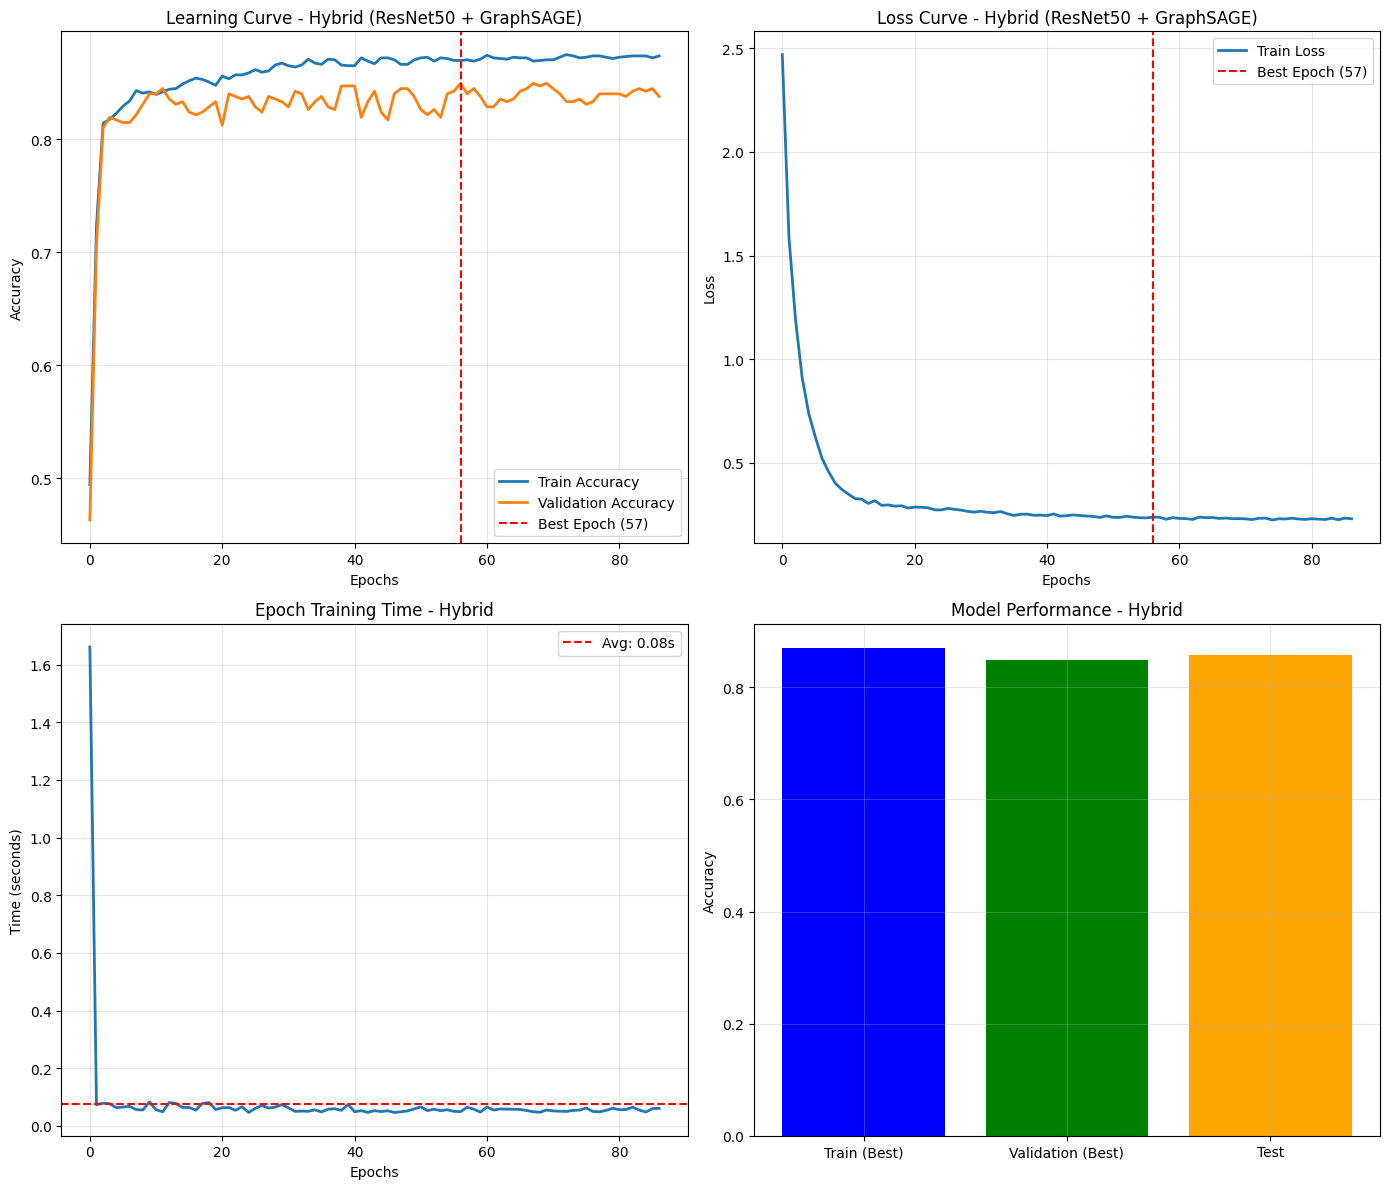

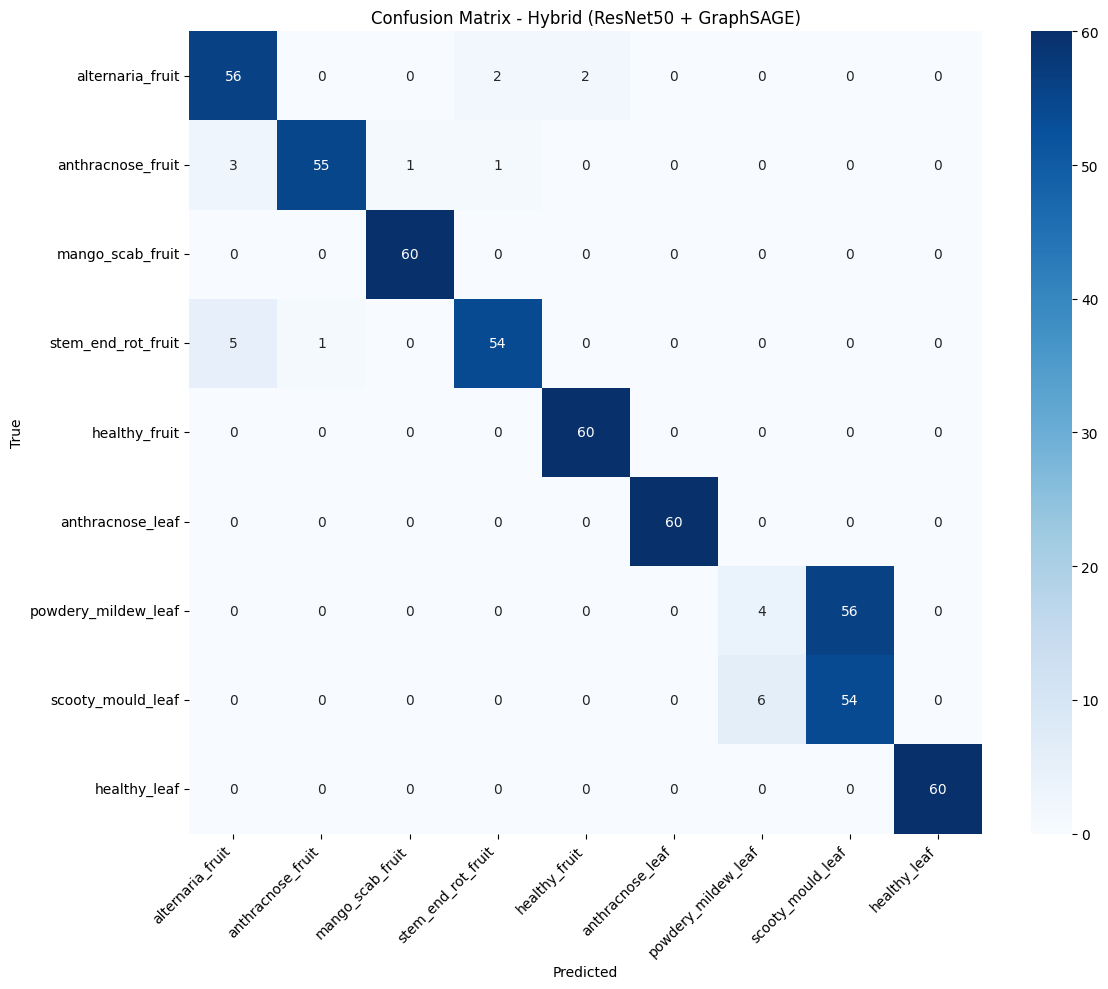

In [ ]:
metrics = {
    'best_epoch': best_epoch,
    'best_val_acc': best_val_acc,
    'total_epochs': len(train_losses),
    'training_time_minutes': train_time / 60,
    'feature_extraction_time_minutes': feat_time / 60,
    'epoch_times_avg': np.mean(epoch_times),
    'epoch_times_std': np.std(epoch_times),
    'train_losses': train_losses,
    'train_accs': train_accs,
    'val_accs': val_accs
}

# Evaluate test
model.load_state_dict(torch.load('hybrid_best123.pt'))
test_acc = evaluate(data.test_mask)
metrics['test_acc'] = test_acc
print(f"Test accuracy: {test_acc:.4f}")

# Per-class metrics
model.eval()
out = model(data)
pred = out.argmax(dim=1).cpu().numpy()
y_test_np = y_test
test_indices = np.where(test_mask)[0]
y_pred_test = pred[test_indices]

class_report = classification_report(y_test_np, y_pred_test, output_dict=True)
metrics['class_report'] = class_report

# Save metrics
with open('hybrid_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# ----------------------------
# 6. Visualizations
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Accuracy plot
axes[0, 0].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[0, 0].plot(val_accs, label='Validation Accuracy', linewidth=2)
axes[0, 0].axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Learning Curve - Hybrid (ResNet50 + GraphSAGE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 1].axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Curve - Hybrid (ResNet50 + GraphSAGE)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Epoch time per epoch
axes[1, 0].plot(epoch_times, linewidth=2)
axes[1, 0].axhline(y=np.mean(epoch_times), color='red', linestyle='--', label=f'Avg: {np.mean(epoch_times):.2f}s')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].set_title('Epoch Training Time - Hybrid')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy comparison bar chart
axes[1, 1].bar(['Train (Best)', 'Validation (Best)', 'Test'],
               [metrics['train_accs'][best_epoch-1], metrics['best_val_acc'], metrics['test_acc']],
               color=['blue', 'green', 'orange'])
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Model Performance - Hybrid')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_learning_curves.png', dpi=300)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_test)
class_names = list(mango_disease_labels.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Hybrid (ResNet50 + GraphSAGE)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('hybrid_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Best Epoch',
        'Best Validation Accuracy',
        'Test Accuracy',
        'Total Training Time (min)',
        'Feature Extraction Time (min)',
        'Avg Epoch Time (s)'
    ],
    'Value': [
        metrics['best_epoch'],
        f"{metrics['best_val_acc']:.4f}",
        f"{metrics['test_acc']:.4f}",
        f"{metrics['training_time_minutes']:.2f}",
        f"{metrics['feature_extraction_time_minutes']:.2f}",
        f"{metrics['epoch_times_avg']:.2f}"
    ]
})
summary.to_csv('hybrid_summary123.csv', index=False)
print("\nResults saved to 'hybrid_summary123.csv'")


Results saved to 'hybrid_summary123.csv'
